# Лабораторная работа № 4

In [70]:
import numpy as np
import math
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def print(string):
    display(Markdown(string))

## Задание 1 <br>

### Задача:<br>

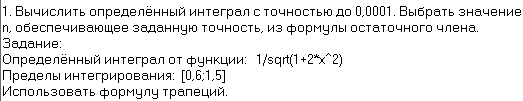

### Решение:

In [71]:
def f(x):
    return 1 / (np.sqrt(1 + 2 * x**2))

def f2(x):
    return (8 * x**2 - 2) / (1 + 2 * x**2)**(2.5)

def trapecia(a, b, N):

    h = (b - a) / N

    result = (f(a) + f(b)) / 2

    for i in range(1, N):
        x = a + i * h
        result += f(x)

    return result * h

def integrate_with_accuracy(a, b, e):
    N = 2

    while True:
        I_N = trapecia(a, b, N)# интеграл при текущем N

        I_2N = trapecia(a, b, 2 * N)# интеграл при удвоенном N

        error = abs(I_2N - I_N) / 3 # погрешность по Рунге

        print(
            f"**N**-{N:<6} | **I_N**-{I_N:<12.8f} | **I_2N**-{I_2N:<12.8f} | **ошибка**-{error:<12.8f}")

        # можно ли заканчивать
        if error < e:
            print(f"\nДостигнута требуемая точность при N = {N}.")
            return I_2N, error
        # можно ли заканчивать

        N *= 2  #продолжаем, удваивая число отрезков

---

In [72]:
a, b = 0.6, 1.5
e = 0.0001

result, achieved_error = integrate_with_accuracy(a, b, e)

print(f"\nИтоговый результат: {result:.8f}")
print(f"Достигнутая погрешность: {achieved_error:.2e}")

**N**-2      | **I_N**-0.51886256   | **I_2N**-0.51498002   | **ошибка**-0.00129418  

**N**-4      | **I_N**-0.51498002   | **I_2N**-0.51402635   | **ошибка**-0.00031789  

**N**-8      | **I_N**-0.51402635   | **I_2N**-0.51378912   | **ошибка**-0.00007908  


Достигнута требуемая точность при N = 8.


Итоговый результат: 0.51378912

Достигнутая погрешность: 7.91e-05

---

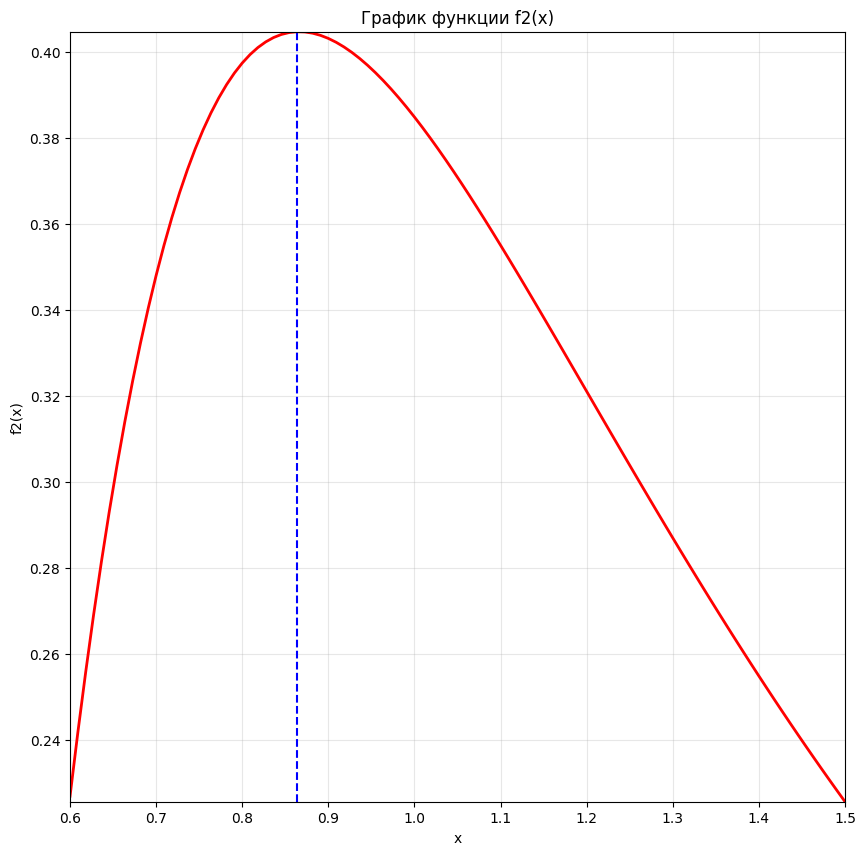

**Максимальное значение f2(x):** 0.404763<br>**при x =** 0.864

In [73]:
xs = np.linspace(a, b, 100)
ys = np.array([f2(x) for x in xs])
maxik = max(ys)

plt.figure(figsize=(10, 10))
plt.xlim(min(xs), max(xs))
plt.ylim(min(ys), max(ys))

plt.plot(xs, ys, 'r', linewidth=2, markersize=8)


plt.axvline(x=xs[np.argmax(ys)], color='b', linestyle='--')#x максимума

plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f2(x)')
plt.title('График функции f2(x)')
plt.show()

print(f"**Максимальное значение f2(x):** {maxik:.6f}<br>**при x =** {xs[np.argmax(ys)]:.3f}")

## Задание 2

### Задача:<br>

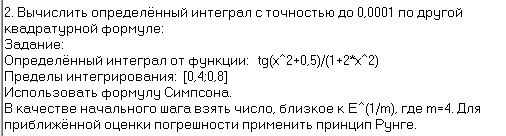

### Решение:

In [74]:
def f(x):
    return np.tan(x**2+0.5) / (1+2*x**2)

def simpson(a, b, n):
    N=2*n

    h = (b - a) / N # шаг разбиения

    xs = [a + i * h for i in range(N + 1)] #иксы с шагом
    ys = [f(x) for x in xs] #значения функций в иксах

    sum = 0

    for k in range(1, N, 2): #сумма значений f(x_i-1)+4*f(x_i)+f(x_i+1) с шагом 2
        ch = ys[k - 1] + 4 * ys[k] + ys[k + 1]
        sum += ch

    I = (h / 3) * sum
    return I

def runge(I_n, I_2n):
    return abs(I_2n - I_n)/15


In [75]:
a = 0.4
b = 0.8
eps = 0.0001
n = 2


I_n = simpson(a, b, n)
I_2n = simpson(a, b, 2*n)

print(f"**I_{n}** ={I_n:.8f}")
print(f"**I_{2*n}** = {I_2n:.8f}")

error_estimate = runge(I_n,I_2n)
print(f"\nПогрешность по Рунге: {error_estimate:.8f}")

print(f"\nПриближенное значение интеграла: {I_2n:.8f}")

**I_2** =0.28184426

**I_4** = 0.28173236


Погрешность по Рунге: 0.00000746


Приближенное значение интеграла: 0.28173236

---

In [76]:
def find_parabola_coefficients(x1, y1, x2, y2, x3, y3):
    # Главный определитель
    D = (x1**2 * (x2 - x3) +
         x2**2 * (x3 - x1) +
         x3**2 * (x1 - x2))
    # Определитель для a
    Da = (y1 * (x2 - x3) +
          y2 * (x3 - x1) +
          y3 * (x1 - x2))
    # Определитель для b
    Db = (x1**2 * (y2 - y3) +
          x2**2 * (y3 - y1) +
          x3**2 * (y1 - y2))
    # Определитель для c
    Dc = (x1**2 * (x2*y3 - x3*y2) +
          x2**2 * (x3*y1 - x1*y3) +
          x3**2 * (x1*y2 - x2*y1))
    # Коэффициенты
    a_coef = Da / D
    b_coef = Db / D
    c_coef = Dc / D
    return a_coef, b_coef, c_coef

def parabola_value(a, b, c, x):#значение параболы в точке x
    return a*x*x + b*x + c

def integral_of_parabola(A, B, C, a, b): #Аналитическое вычисление интеграла от параболы
    F = lambda x: A*x**3/3 + B*x**2/2 + C*x
    return F(b) - F(a)

In [77]:
x1, x2, x3 = a, (a + b) / 2, b #начало середина конец
y1, y2, y3 = f(x1), f(x2), f(x3) #функции от иксов

print(f"Точка 1: ({x1:.4f}, {y1:.6f})")
print(f"Точка 2: ({x2:.4f}, {y2:.6f})")
print(f"Точка 3: ({x3:.4f}, {y3:.6f})")


Точка 1: (0.4000, 0.587958)

Точка 2: (0.6000, 0.675323)

Точка 3: (0.8000, 0.954331)

In [78]:
# коэффициенты параболы
A, B, C = find_parabola_coefficients(x1, y1, x2, y2, x3, y3)
print(f"\nУравнение параболы: P(x) = {A:.6f}x² + {B:.6f}x + {C:.6f}")


# интеграл от параболы
integral_parabola = integral_of_parabola(A, B, C, a, b)
print(f"Интеграл от параболы на [{a}, {b}]: {integral_parabola:.8f}")


Уравнение параболы: P(x) = 2.395539x² + -1.958714x + 0.988158

Интеграл от параболы на [0.4, 0.8]: 0.28290548

In [79]:
# проверка прохождения параболы через точки

print(f"P({x1:.4f}) = {parabola_value(A, B, C, x1):.10f} (должно быть {y1:.10f})  **{'верно' if abs(parabola_value(A, B, C, x1) - y1) < 1e-9 else 'неправильно'}**")
print(f"P({x2:.4f}) = {parabola_value(A, B, C, x2):.10f} (должно быть {y2:.10f})  **{'верно' if abs(parabola_value(A, B, C, x2) - y2) < 1e-9 else 'неправильно'}**")
print(f"P({x3:.4f}) = {parabola_value(A, B, C, x3):.10f} (должно быть {y3:.10f})  **{'верно' if abs(parabola_value(A, B, C, x3) - y3) < 1e-9 else 'неправильно'}**")

P(0.4000) = 0.5879582673 (должно быть 0.5879582673)  **верно**

P(0.6000) = 0.6753231731 (должно быть 0.6753231731)  **верно**

P(0.8000) = 0.9543311979 (должно быть 0.9543311979)  **верно**

In [80]:
# графики

# точки для построения графиков
x_plot = np.linspace(a - 0.05, b + 0.05, 500)
y_func = [f(x) for x in x_plot]
y_parabola = [parabola_value(A, B, C, x) for x in x_plot]
# точки для построения графиков

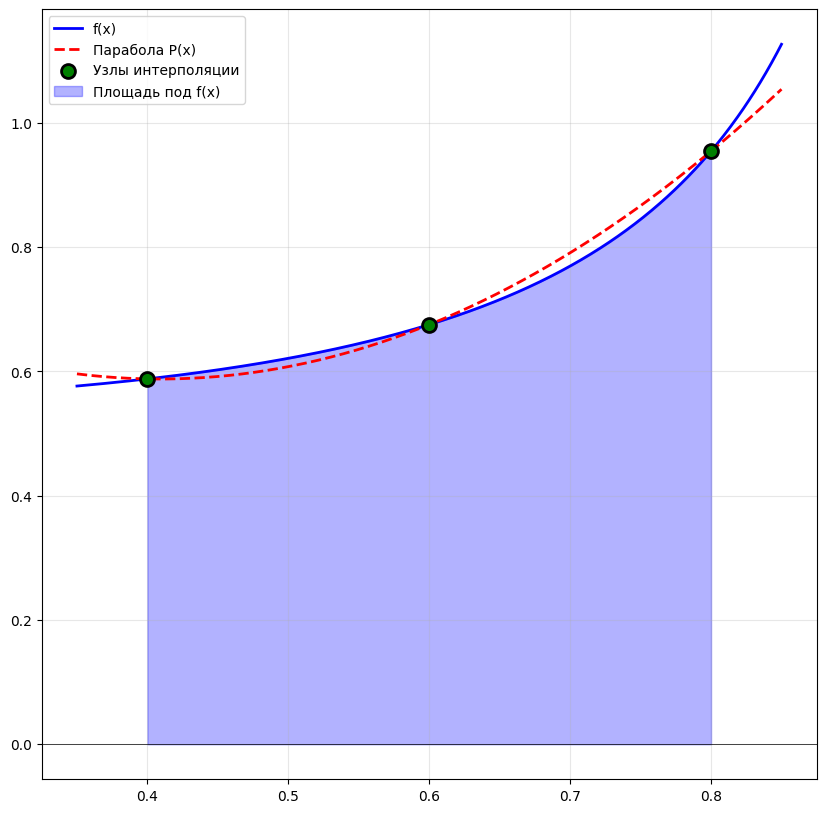

In [81]:
# ГРАФИК 1: Функция и парабола
plt.figure(figsize=(10, 10))


plt.plot(x_plot, y_func, 'b-', linewidth=2, label='f(x)')
plt.plot(x_plot, y_parabola, 'r--', linewidth=2, label='Парабола P(x)')
plt.scatter([x1, x2, x3], [y1, y2, y3], color='green', s=100, zorder=5,
            label='Узлы интерполяции', edgecolors='black', linewidth=2)


# площадь под функцией
x_fill = np.linspace(a, b, 100)
y_fill = [f(x) for x in x_fill]
plt.fill_between(x_fill, 0, y_fill, alpha=0.3, color='blue', label='Площадь под f(x)')
# площадь под функцией


plt.axhline(y=0, color='black', linewidth=0.5)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)


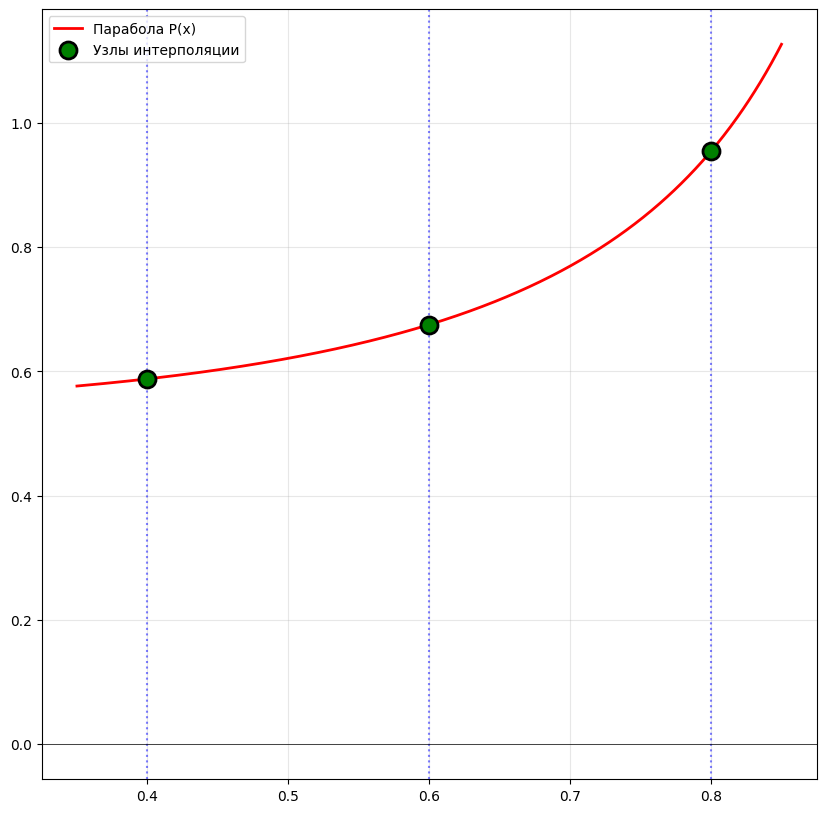

In [82]:

# ГРАФИК 2: Только парабола
plt.figure(figsize=(10, 10))


plt.plot(x_plot, y_func, 'r-', linewidth=2, label='Парабола P(x)')
plt.scatter([x1, x2, x3], [y1, y2, y3], color='green', s=150, zorder=5,
            label='Узлы интерполяции', edgecolors='black', linewidth=2)


# Вертикальные линии в точках интерполяции
for xi in [x1, x2, x3]:
    plt.axvline(x=xi, color='b', linestyle=':', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)



In [83]:
# оценка точности

# Вычисляем максимальную ошибку на всём интервале
x_error = np.linspace(a, b, 200)
errors = [abs(parabola_value(A, B, C, x) - f(x)) for x in x_error]
mean_error = np.mean(errors)

print(f"Средняя ошибка аппроксимации: {mean_error:.2e}")

# Находим точку максимальной ошибки
x_max_error = x_error[np.argmax(errors)]
print(f"Точка максимальной ошибки: x = {x_max_error:.4f}")

Средняя ошибка аппроксимации: 1.18e-02

Точка максимальной ошибки: x = 0.7296

---

## Задание 3

### Задача:<br>

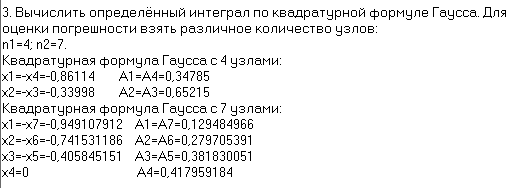

### Решение:

In [84]:
def f3(x):
    return (x + 1) / np.sqrt(x**2 + 1)
def f5(x):
    return x**5 - 2*x**4 + 3*x**3 - 4*x**2 + 5*x - 6
def f12(x):
    return x**12
def gauss_quadrature(a, b, nodes, weights):
    transform = lambda t: (b - a) / 2 * t + (b + a) / 2
    integral = (b - a) / 2 * np.sum(weights * f3(transform(nodes)))
    return integral

def gauss_quadrature_poly(a, b, nodes, weights, func):
    """Квадратура Гаусса для произвольной функции"""
    transform = lambda t: (b - a) / 2 * t + (b + a) / 2
    integral = (b - a) / 2 * np.sum(weights * func(transform(nodes)))
    return integral


In [85]:
a, b = -0.4, 1.6

# Квадратурная формула Гаусса с 4 узлами
nodes_4 = np.array([-0.86114, -0.33998, 0.33998, 0.86114])
weights_4 = np.array([0.34785, 0.65215, 0.65215, 0.34785])
# Квадратурная формула Гаусса с 4 узлами

# Квадратурная формула Гаусса с 7 узлами
nodes_7 = np.array([-0.949107912, -0.741531186, -0.405845151, 0.0,
                     0.405845151, 0.741531186, 0.949107912])
weights_7 = np.array([0.129484966, 0.279705391, 0.381830051, 0.417959184,
                      0.381830051, 0.279705391, 0.129484966])
# Квадратурная формула Гаусса с 7 узлами


I4 = gauss_quadrature(a, b, nodes_4, weights_4)
I7 = gauss_quadrature(a, b, nodes_7, weights_7)

In [86]:
print(f"Интеграл по формуле Гаусса (n=4): {I4:.8f}")
print(f"Интеграл по формуле Гаусса (n=7): {I7:.8f}")
print(f"Оценка погрешности (|I7 - I4|):   {abs(I7 - I4):.2e}")
print(f"\nПриближённое значение интеграла: {I7:.8f} ± {abs(I7 - I4):.2e}")

Интеграл по формуле Гаусса (n=4): 2.44930871

Интеграл по формуле Гаусса (n=7): 2.44878272

Оценка погрешности (|I7 - I4|):   5.26e-04


Приближённое значение интеграла: 2.44878272 ± 5.26e-04

In [87]:
a_poly, b_poly = -1.0, 1.0

exact_5 = -15.4666666

I4_poly = gauss_quadrature_poly(a_poly, b_poly, nodes_4, weights_4, f5)
I7_poly = gauss_quadrature_poly(a_poly, b_poly, nodes_7, weights_7, f5)

print(f"Точное значение интеграла:        {exact_5:.8f}")
print(f"Квадратура Гаусса (n=4):          {I4_poly:.8f}")
print(f"Квадратура Гаусса (n=7):          {I7_poly:.8f}")
print(f"Погрешность n=4:                  {abs(I4_poly - exact_5):.2e}")
print(f"Погрешность n=7:                  {abs(I7_poly - exact_5):.2e}")


Точное значение интеграла:        -15.46666660

Квадратура Гаусса (n=4):          -15.46665866

Квадратура Гаусса (n=7):          -15.46666666

Погрешность n=4:                  7.94e-06

Погрешность n=7:                  6.26e-08

In [88]:
exact_12 = 2 / 13

I4_poly12 = gauss_quadrature_poly(a_poly, b_poly, nodes_4, weights_4, f12)
I7_poly12 = gauss_quadrature_poly(a_poly, b_poly, nodes_7, weights_7, f12)

print(f"Точное значение интеграла:        {exact_12:.8f}")
print(f"Квадратура Гаусса (n=4):          {I4_poly12:.8f}")
print(f"Квадратура Гаусса (n=7):          {I7_poly12:.8f}")
print(f"Погрешность n=4:                  {abs(I4_poly12 - exact_12):.2e}")
print(f"Погрешность n=7:                  {abs(I7_poly12 - exact_12):.2e}")

Точное значение интеграла:        0.15384615

Квадратура Гаусса (n=4):          0.11569613

Квадратура Гаусса (n=7):          0.15384615

Погрешность n=4:                  3.82e-02

Погрешность n=7:                  7.07e-10

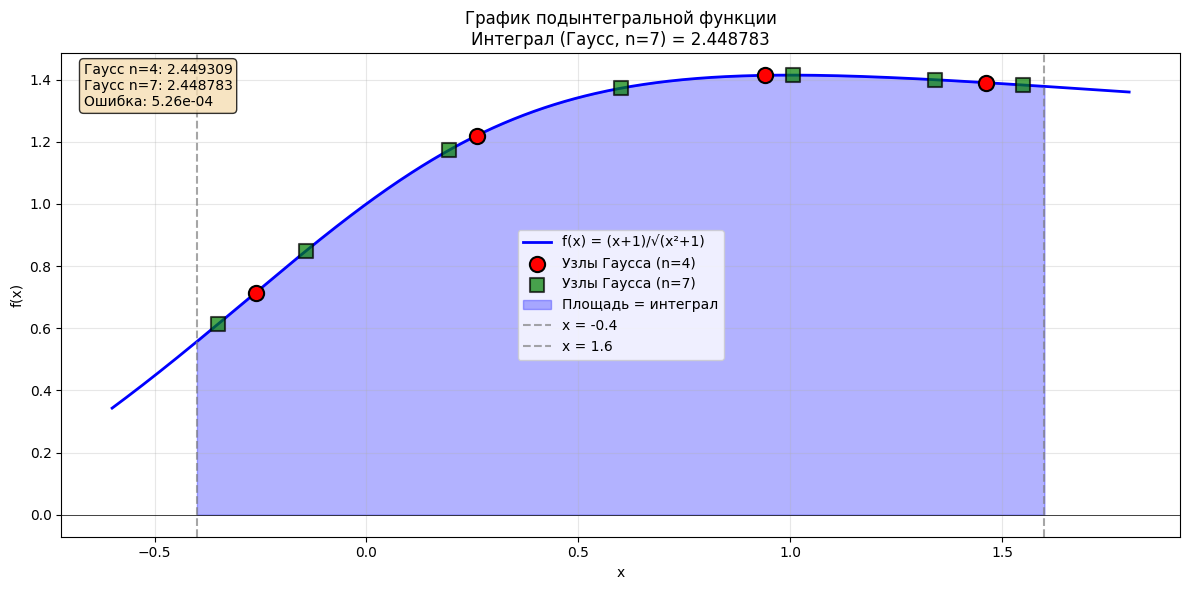

In [89]:
# Создаём точки для графика
x_plot = np.linspace(a - 0.2, b + 0.2, 500)
y_plot = [f3(x) for x in x_plot]

# Находим узлы Гаусса на [a, b]
transform = lambda t: (b - a) / 2 * t + (b + a) / 2
x_nodes_4 = transform(nodes_4)
x_nodes_7 = transform(nodes_7)
y_nodes_4 = f3(x_nodes_4)
y_nodes_7 = f3(x_nodes_7)

plt.figure(figsize=(12, 6))

# График функции
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x) = (x+1)/√(x²+1)')

# Узлы Гаусса
plt.scatter(x_nodes_4, y_nodes_4, color='red', s=120, zorder=5,
            label='Узлы Гаусса (n=4)', marker='o', edgecolors='black', linewidth=1.5)
plt.scatter(x_nodes_7, y_nodes_7, color='green', s=90, zorder=5,
            label='Узлы Гаусса (n=7)', marker='s', edgecolors='black', linewidth=1.5, alpha=0.7)

# Закрашиваем площадь
x_fill = np.linspace(a, b, 200)
y_fill = [f3(x) for x in x_fill]
plt.fill_between(x_fill, 0, y_fill, alpha=0.3, color='blue', label='Площадь = интеграл')

# Оформление
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=a, color='gray', linestyle='--', alpha=0.7, label=f'x = {a}')
plt.axvline(x=b, color='gray', linestyle='--', alpha=0.7, label=f'x = {b}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'График подынтегральной функции\nИнтеграл (Гаусс, n=7) = {I7:.6f}')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Добавляем информацию на график
textstr = f'Гаусс n=4: {I4:.6f}\nГаусс n=7: {I7:.6f}\nОшибка: {abs(I7 - I4):.2e}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()



## Задание 4

### Задача:<br>


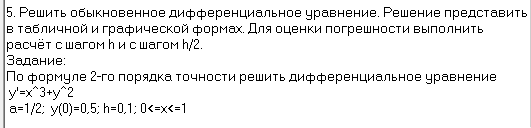

### Решение:

In [90]:
def func(x, y):
    return x**3 + y**2

def solve_ode_2order(x_start, x_end, y_initial, step):
    x_vals = [x_start]
    y_vals = [y_initial]

    current_x = x_start
    current_y = y_initial

    steps_count = int((x_end - x_start) / step)

    for _ in range(steps_count):
        # Предиктор
        k1 = func(current_x, current_y)
        y_predictor = current_y + step * k1

        # Корректор
        k2 = func(current_x + step, y_predictor)
        current_y = current_y + (step / 2.0) * (k1 + k2)
        current_x += step

        x_vals.append(current_x)
        y_vals.append(current_y)

    return x_vals, y_vals


In [91]:
left_border = 0.0
right_border = 1.0
initial_y = 0.5
step_large = 0.1
step_small = 0.05


x_large, y_large = solve_ode_2order(left_border, right_border, initial_y, step_large)
x_small, y_small = solve_ode_2order(left_border, right_border, initial_y, step_small)

runge_errors = []
for i in range(len(x_large)):
    y_at_same_x = y_small[2 * i]
    error = abs(y_large[i] - y_at_same_x) / 3.0
    runge_errors.append(error)


print("│    x    │   y(x) h=0.1 │")
print("───────────")
for i in range(len(x_large)):
    print(f"│ {x_large[i]:5.1f}   │  {y_large[i]:.6f}  │")
print("---")

print("│    x    │   y(x) h=0.05│")
print("───────────")
for i in range(0, len(x_small), 2):
    print(f"│ {x_small[i]:5.1f}   │  {y_small[i]:.6f}  │")
print("---")

print("│    x    │  Погрешность  │")
print("───────────")
for i in range(len(x_large)):
    print(f"│ {x_large[i]:5.1f}   │   {runge_errors[i]:.2e}   │")
print("---")

print(f"Максимальная погрешность: {max(runge_errors):.2e}")
print(f"Средняя погрешность:       {sum(runge_errors)/len(runge_errors):.2e}")
print(f"Погрешность в x=1: {runge_errors[-1]:.2e}")


│    x    │   y(x) h=0.1 │

───────────

│   0.0   │  0.500000  │

│   0.1   │  0.526331  │

│   0.2   │  0.555986  │

...

│   1.0   │   1.20e-03   │

---

Максимальная погрешность: 1.20e-03

Средняя погрешность:       1.84e-04

Погрешность в x=1: 1.20e-03

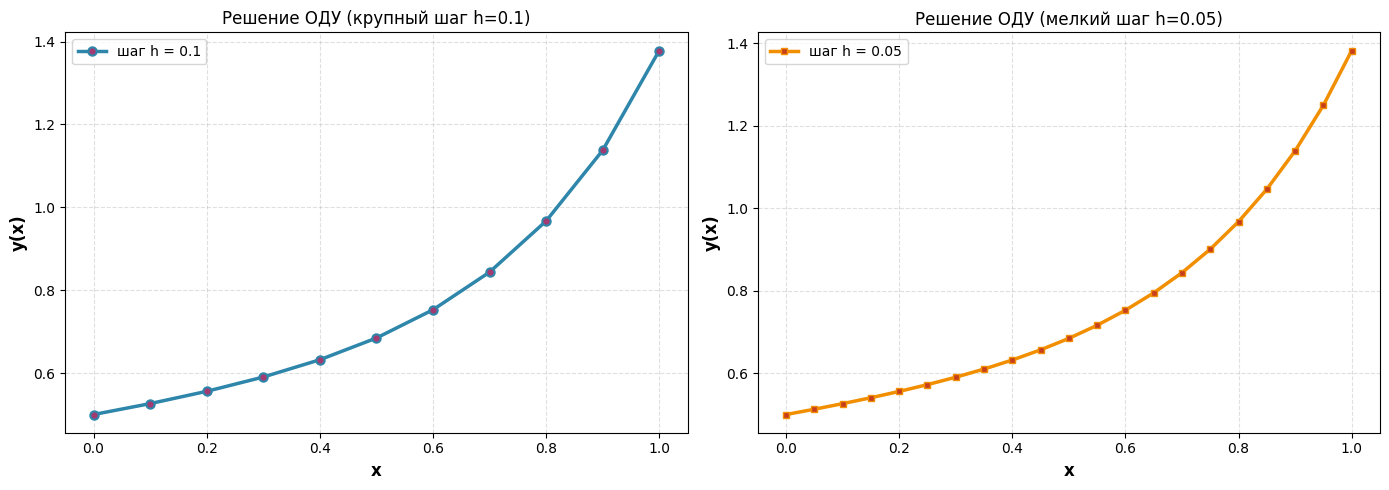

In [92]:
# рисунок с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Левый график: решение с шагом h = 0.1
axes[0].plot(x_large, y_large, 'o-', color='#2E86AB', linewidth=2.5,
             markersize=6, markerfacecolor='#A23B72', markeredgewidth=1.5,
             label=f'шаг h = {step_large}')
axes[0].set_xlabel('x', fontsize=12, fontweight='bold')
axes[0].set_ylabel('y(x)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Решение ОДУ (крупный шаг h={step_large})', fontsize=12)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.4, linestyle='--')
axes[0].set_xlim([-0.05, 1.05])


# Правый график: решение с шагом h = 0.05
axes[1].plot(x_small, y_small, 's-', color='#F18F01', linewidth=2.5,
             markersize=4, markerfacecolor='#C73E1D', markeredgewidth=1,
             label=f'шаг h = {step_small}')
axes[1].set_xlabel('x', fontsize=12, fontweight='bold')
axes[1].set_ylabel('y(x)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Решение ОДУ (мелкий шаг h={step_small})', fontsize=12)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.4, linestyle='--')
axes[1].set_xlim([-0.05, 1.05])

plt.tight_layout()
plt.show()



# plt.figure(figsize=(10, 5))
# plt.plot(x_large, runge_errors, 'ro-', linewidth=1.5, markersize=6, alpha=0.5)
# plt.xlabel('x', fontsize=12, fontweight='bold')
# plt.ylabel('Оценка погрешности', fontsize=12, fontweight='bold')
# plt.title('Оценка глобальной погрешности по правилу Рунге (p=2)', fontsize=12)
# plt.grid(True, alpha=0.3, axis='y')
# plt.show()
